<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/unsupervised/lab3_clustering_basic_%26_input.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 1:** Randomly select two attributes (i.e., features), and print the data on screen and visualize it in 2 different ways choosing image (imshow), line plot (plot), or scatterplot (either sns.scatterplot or plot).

In [3]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [4]:
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [5]:
path = "/content/drive/MyDrive/Unsupervised/Clustering/Dataset_lab03.npy"

In [6]:
data = np.load(path)
data.shape

(30, 11)

(array([4, 6]), (30, 2))

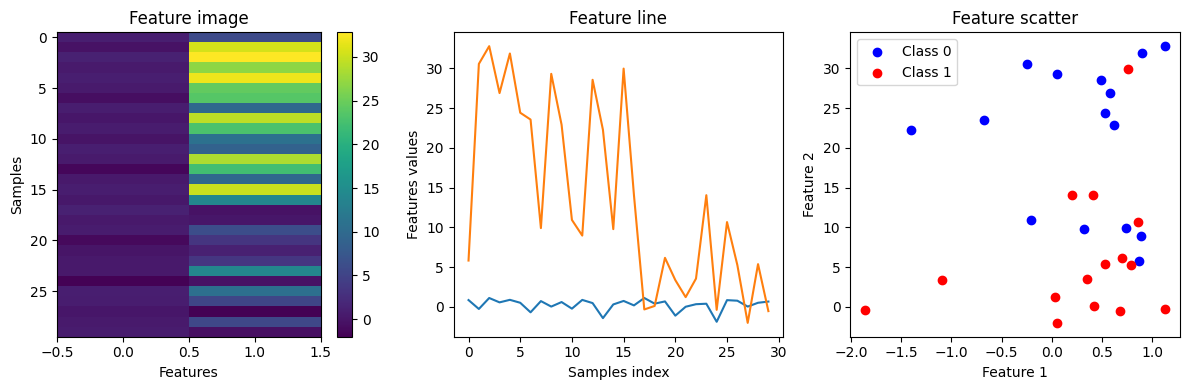

In [9]:
# get the rundom feature index
idxs = np.random.randint(0, data.shape[1], size=2)
# get the random featurs
random_features = data[:, idxs]
# plot them in 3 diffirent ways
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
# plot image
aximg = ax[0].imshow(random_features, aspect='auto')
ax[0].set_title("Feature image")
ax[0].set_xlabel("Features")
ax[0].set_ylabel("Samples")
fig.colorbar(aximg, ax=ax[0])

# plot line
ax[1].plot(random_features)
ax[1].set_title("Feature line")
ax[1].set_xlabel("Samples index")
ax[1].set_ylabel("Features values")

# plot scatter
labels = data[:, -1]
ax[2].scatter(x=random_features[labels==0, 0], y=random_features[labels==0, 1], color='blue', label="Class 0")
ax[2].scatter(x=random_features[labels==1, 0], y=random_features[labels==1, 1], color='red', label="Class 1")
ax[2].set_title("Feature scatter")
ax[2].set_xlabel("Feature 1")
ax[2].set_ylabel("Feature 2")
ax[2].legend()

plt.tight_layout()
idxs, random_features.shape

**Task 3:** Compute the proximity matrix and plot it.

**Note that the proximity values depend on the choice of the attributes that you use to represent objects.**

(30, 30)

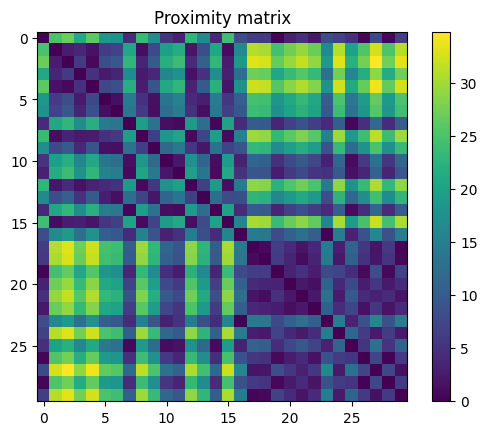

In [10]:
# get the distance
eu_distance = sklearn.metrics.pairwise.pairwise_distances(X=random_features, metric='euclidean')
plt.imshow(eu_distance)
plt.title("Proximity matrix")
plt.colorbar()
eu_distance.shape

**Task 4:** Compute the "centroids", i.e., the mean point of each group of objects, _using only the two selected attributes_ and print their coordinates.

The centroid of cluster 0 has cordinate of [ 0.306 21.248]
The centroid of cluster 1 has cordinate of [0.264 6.05 ]


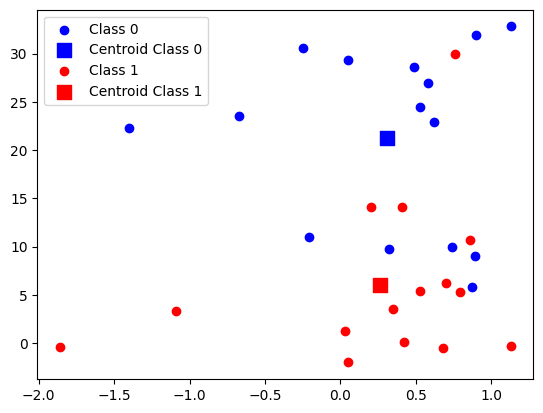

In [12]:
K=2
centroidk = np.zeros(shape=(K, random_features.shape[1]))
color = ['blue', 'red']
for i in range(K):
  centroidk[i,:] =  [random_features[data[:, -1]==i, 0].mean(), random_features[data[:, -1]==i, 1].mean()]
  print(f'The centroid of cluster {i} has cordinate of {centroidk[i, :]}')

  # TASK4b: Plot the centroids for all groups in the same figure
  plt.scatter(x=random_features[data[:, -1]==i, 0], y=random_features[data[:, -1]==i, 1], color=color[i],  label=f"Class {i}" )
  plt.scatter(x=centroidk[i, 0], y=centroidk[i, 1], marker='s', color=color[i], s=100, label=f"Centroid Class {i}")

plt.legend()


**Task 5:** Compute the intra-cluster distance (d) and the inter-cluster distance (D). Print both values.

Use the following definitions:
*   **intra-cluster distance**: average distance between the pairwise distances of all objects in the cluster (i.e., group)
*   **inter-cluster distance**: distance between centroids.

In [27]:
cluster0 = random_features[data[:, -1]==0]
centroid0 = centroidk[0]
# how far each point is from the center (in x and y)”
point0_d_center  = cluster0-centroid0
# compute distance (length)
d0 = np.linalg.norm(point0_d_center, axis=1)
# compute the intra cluster distance
intra_cluster0_distance = d0.mean()

cluster1 = random_features[data[:, -1]==1]
centroid1 = centroidk[1]
point1_d_center = cluster1-centroid1
d1 = np.linalg.norm(point1_d_center, axis=1)
intra_cluster1_distance = d1.mean()

intra_cluster0_distance, intra_cluster1_distance

(np.float64(8.189113017557185), np.float64(6.050175076446217))

In [32]:
inter_distance = np.linalg.norm(centroidk[0]-centroidk[1])
# --------- or ---------
# centroid_distance = sklearn.metrics.pairwise.pairwise_distances(centroidk, metric='euclidean')
# inter_distance = centroid_distance[0, 1]
inter_distance

np.float64(15.198058033841033)

**Task 6** Answer the following question in your lab report, adding a short motivation.

**Question:** "Based on inter-/intra-cluster distances, do you think the found one is a good clustering solution?"

**MY SOLUTION:** The clustering result appears to be good. The intra-cluster distances (8.19 and 6.05) are significantly smaller than the inter-cluster distance (15.20). This indicates that the data points within each cluster are relatively close to each other (high compactness), while the clusters themselves are well separated from each other. Therefore, the clustering shows good separation and cohesion.